# Table of Contents
1. [PPP for Network Generation](#ppp-for-network-generation)
2. [Kalman Filter for SOs Estimations](#kalman-filter-for-sos-estimations)
3. [Performance Analysis](#performance-analysis)  
   3.A. [Shannon Rate vs Interference](#shannon-rate-vs-interference)  
   3.B. [Coverage Probability vs Interference](#coverage-probability-vs-interference)


In [1]:
pip install -r simulation_files/utils/requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Set Simulation Memory

In [2]:
import os
id = 0
output_dir = f'simulator_output/fig_{id}'
os.makedirs(output_dir, exist_ok=True)

## Environment Settings

### Set Radio Propagation Parameters

In [ ]:
2.250 * 4 * 2.000
#km^2

59/18 #3.33 BS per KM^2

1/3.33 #0.3 km^2 per BS of area

import math
math.sqrt(1/3.33) circa 500m di coverage

0.547996624351191

In [3]:
from simulation_files.network_generator.radio_env_builder import *
x = 2250 #1000
y = 2000 #750 
area = x*y 

In [4]:
generate_radio_env_file(
    FC = 3.5e9,W = 20e6,N = -125,ALPHA = 2.7,PW_TX = 46,
    G_TX_main = 23,G_TX_side = 3, G_RX=0,net_width=x, net_height=y)

File successfully created at: simulation_files/network_generator/radio_env.py


### Generate Network Environment

In [5]:
from simulation_files.network_generator.network_builder import *
intensity_bss = 12/area
intensity_sos = None
intensity_ues = None
cnt, ues_pos, sos_pos = build_tasselation(intensity_bss=intensity_bss, intensity_sos=intensity_sos, intensity_ues=intensity_ues)

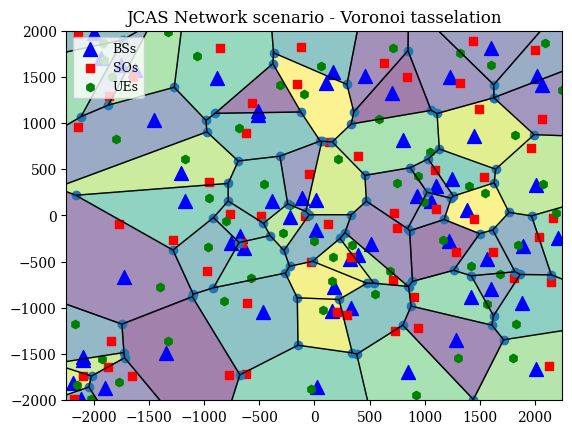

In [6]:
# Plot the tasselation
voronoi_fig = voronoi_plot_2d(cnt.bss_voronoi, show_points=False, show_vertices=True)
plt.figure(voronoi_fig.number) 
cnt.plot_network(sos_pos=sos_pos, ues_pos=ues_pos, title='JCAS Network scenario - Voronoi tasselation')
plt.savefig(f"{output_dir}/network_tassellation.png")
plt.show()

## Simulation

### Parameters Choiche

In [7]:
n_steps = 1000
velox_range_km_h = [5,10]

velox_domain = apply_lambda(func=convert_to_m_per_s , lst=velox_range_km_h)

args_so = {
    "velox_domain": velox_domain,  # Convert km/h to m/s
    "obs_dim": 2,  
    "motion_scaler": 0.9,  
    "obs_scaler": 10,  #($\delta$)
    "motion_noise_scaler": 10, #($\kappa$)
    "sigma0": 1,  
    "thr_so":500,
    "so_motionless":False, 
}
args_ue = {
    "velox_domain": velox_domain,  # Replace with actual domain list
    "arrival_rate": 10,  # Arrival rate parameter
    "scaler": 2,  # Motion scaling factor
    "thr_ue": 500,
    "user_motionless": True,
}
args_bs = {
    'lambda_bss' : intensity_bss,
}
tail = False
show_samples = False
verbose = True
valid_modes = ['jcas', 'sen', 'com']
mode = valid_modes[2] 

### Simulation Run

In [8]:
from simulation_files.simulator_backbone.simulator import *
bss = cnt.bs_map
sos = cnt.sos_map
ues = cnt.ues_map

In [9]:
print(f'Number of BSs: {len(bss)}')
print(f'Number of SOs: {len(sos)}')
print(f'Number of UEs: {len(ues)}')

Number of BSs: 59
Number of SOs: 59
Number of UEs: 59


Running simulation: 100%|██████████| 1000/1000 [01:11<00:00, 14.04it/s]


| Radio Environment Parameters                  | Value                                           |
|-----------------------------------------------|-------------------------------------------------|
| $N_{BSs}$,$N_{UEs}$,$N_{SOs}$                 | (59, 59, 0)                                     |
| Area                                          | 18.0 $\text{km}^2$                              |
| Central Frequency ($f_c$)                     | 3.5 GHz                                         |
| Noise ($N$)                                   | -52.0 dBm                                       |
| Bandwidth ($W$)                               | 20.0 MHz                                        |
| Transmitting Power ($P_{tx}$)                 | 46 dBm                                          |
| Free-space path loss ($L_{0}$)                | 43.3 dB/$d_{0}$ where $d_{0} = 1$ m             |
| Antenna Gain TX - Main Lobe ($G_{tx}$)        | 23 dBi                                          |
| Antenna Gain TX - Side Lobe ($G_{tx}$)        | 3 dBi                                           |
| Antenna Gain RX (UE) ($G_{tx}$)               | 0 dBi                                           |
| Small Scale Fading ($H(t)$)                   | $H(t) \sim Exp(1)$ (Exp. = $\text{Rayleigh}^2$) |
| Path Loss expoent ($\alpha$)                  | 2.7                                             |
| $\bar \xi(0)$ - Typical BS Interference Filed | -47.6 dBm                                       |

| KF and Queues Parameters    | Value                                                |
|-----------------------------|------------------------------------------------------|
| $\lambda_{BS}$              | 2.666666666666667e-06$\frac{\text{BS}}{\text{km}^2}$ |
| $\delta$                    | 10                                                   |
| $\kappa$                    | 10                                                   |
| $\sigma_0$                  | 1                                                    |
| Object Velocity             | $ \mathcal{U} $ ([5.0, 10.0]) (km/h)                 |
| Simulation time             | 1000 (s)                                             |
| $\tau_W$,$\tau_\Sigma$      | (500, 500)                                           |
| $\forall s \in \mathcal{M}$ | $\lambda_{arr}$= 10.0, $\rho$= 0.9                   |

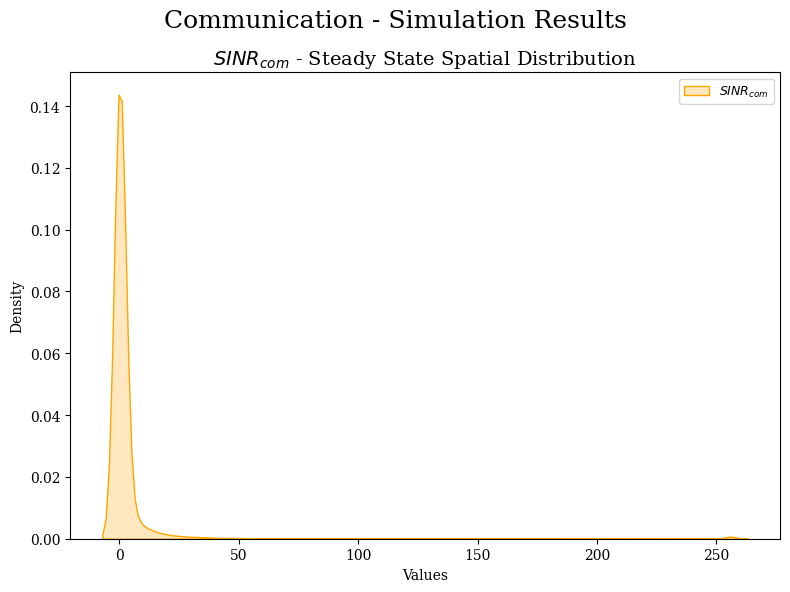

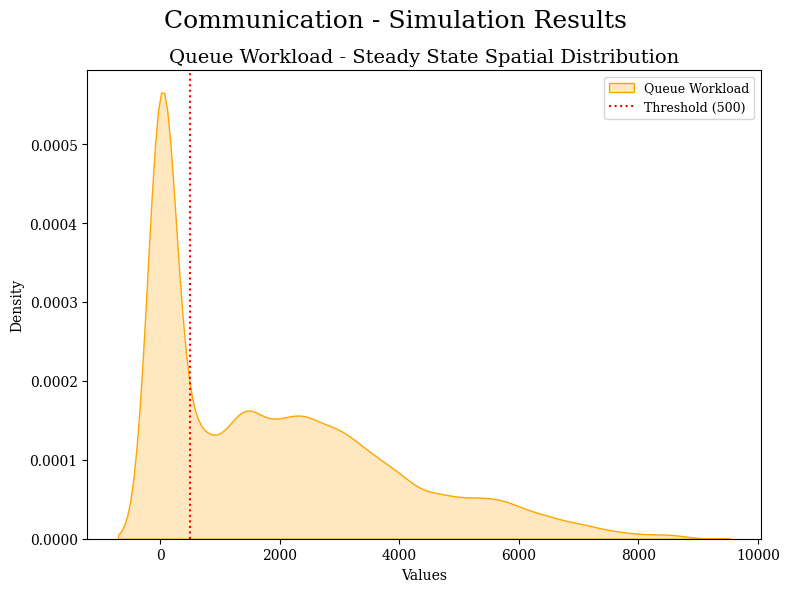

In [10]:
#Run Simulation
sim = Simulation(save_dir = output_dir, bss=bss, sos=sos,ues=ues, t_max=n_steps, show_samples=show_samples, verbose=verbose, mode=mode)
sim.run(args_so = args_so, args_ue = args_ue, args_bs = args_bs, tail = tail)

### Trajectories visualization

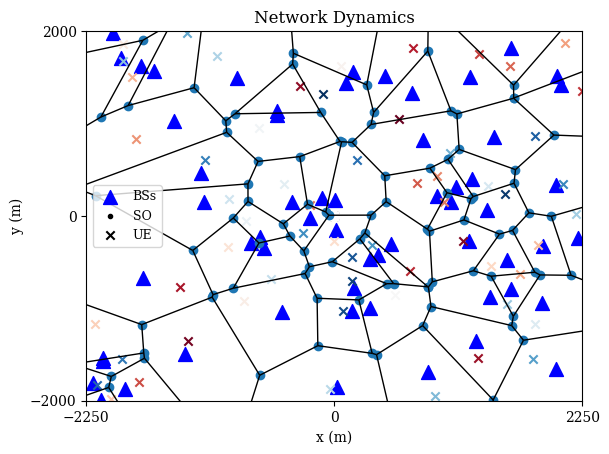

In [11]:
sos_trajs = {so.id: so.theta for so in sos}  if mode.lower() != 'com' else None
ues_trajs = {ue.id: ue.theta for ue in ues} if mode.lower() != 'sen' else None
voronoi_fig = voronoi_plot_2d(cnt.bss_voronoi, show_points=False, show_vertices=True)
cnt.plot_trajectory(save_dir = sim.save_dir, sos_traj=sos_trajs, ues_traj=ues_trajs, title='Network Dynamics')

### JCAS - Positive Association Analysis

In [12]:
if mode == 'jcas':
    voronoi_fig = voronoi_plot_2d(cnt.bss_voronoi, show_points=False, show_vertices=True)
    cnt.plot_spatial_heatmap(save_dir = sim.save_dir, title='Steady-Steate Spatial Correlation',tail=tail)